# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is considered "linear" when the parameters have a linear relationship through an equation in the form of y = b + mg + nh + oi... where m, n, o are the parameters with corresponding predictors g, h, i and a y intercept b to determine a final y target variable. In other words, y can be expressed as a linear combination of the parameters. The coeficients of these parameters are what are linear. 


2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

The dummy variable can be used to determine the weights of other parameters in terms of a baseline group. If we keep the y-intercept, the y intercept would represent the mean fo the baseline group's values. The other coefficients corresponding to the parameters would be the difference between the mean of the baseline and the specific parameter. Now every parameter is in reference to the baseline group. If we drop the y-intercept, then each coefficient is the mean of it's group. 

3. Can linear regression be used for classification? Explain why, or why not.

Yes, a linear regression can be used for classifications by setting thresholds for y which indicate particular classes. However, a linear regression is not ideal for classifications as linear combinations can differ significantly while also outputting similar y values. Because the coefficients are no based on class probability rates as well it would not work well in classifications. 

4. What are signs that your linear model is over-fitting?

Overfitting occurs when a model uses information that is too specific to the training data such as noise and outliers, and therefore when applied to other data it will look for trends that are specifically aligned with the training data rather than to data in general. You can identifiy if a model is over fitted by looking to see if the prediction accuracy is very high (low error) for the training data and relatively low for the test data. This is why it is important to check the errors for training and testing data. 

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multi-colinearity is when two or more variables are strongly correlated to one another. This means that the values of one are very good predictors of the values of the other, and vise versa. For two stage least square, when looking at two predictors that are very correlated, you can pick one predictor and seperate the data to include only the trend that can not be explained by the other predictor. Then you can regress that on the y variable Once you idenitify a variation in the predictor variable that is not explained by others, then you can regress the outcome on the cleanded predictor. When the correlation is very strong like with multicollinearity, then it is difficult to split the data in this way. Therefore the data set is very small and will have unstable trends. 

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

You can use polynomial features to make your model more complex by expanding x variable with higher powers (e.g. x, x^2, x^3...) which allow the model to fit in a curve shape to allow for more accuracy. You can also use log operation to translate the relationship to be more interpretable as it stablizes the variance more by reducing the power of outliers. 

7. What is the interpretation of the slope coefficient in a linear regression?

The slope coefficient is the amount the x variable increases per one unit of the y variable. 

8. Compare the train/test split and $k$-fold cross validation.

The train/test split is a single split method whereas the k-fold splits the data multiple times. Train/test split is heavily dependent on what training data is selected and therefore is susceptible to high variance. K-fold cross validation splits the data into k folds and averages the seperated data scores. This is much more stable and uses all the data in training and testing. 

9. How is the $k$ in $k$-fold cross validation typically selected?
When k is larger, you train on almost all the data which means lower bias (unlike train/test spilt with only one fold), but then you are only testing on tiny slices which means it is more unstable and produces noisy estimates and thus there is higher variance. It is important to balence the bias and variance so that the mean cross validation is optimal. 

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [358]:
#Q2.0 cleaning data 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression


df = pd.read_csv("./data/Q1_clean.csv")
print(df.head())
df.columns
df = df.rename(columns = {"Neighbourhood ": "Neighborhood"})
print(df.info())


   Price  Review Scores Rating Neighbourhood  Property Type        Room Type
0    549                  96.0      Manhattan     Apartment     Private room
1    149                 100.0       Brooklyn     Apartment  Entire home/apt
2    250                 100.0      Manhattan     Apartment  Entire home/apt
3     90                  94.0       Brooklyn     Apartment     Private room
4    270                  90.0      Manhattan     Apartment  Entire home/apt
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22153 entries, 0 to 22152
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Price                 22153 non-null  int64  
 1   Review Scores Rating  22153 non-null  float64
 2   Neighborhood          22153 non-null  object 
 3   Property Type         22153 non-null  object 
 4   Room Type             22153 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 865.5+ KB
None


In [359]:
#Q2.1 Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? 
# Create a kernel density plot of price and log price, grouping by `Neighbourhood`.


# averaging price and score
price_ave = df['Price'].mean()
score_ave = df['Review Scores Rating'].mean()

print('average price:', price_ave)
print('average score:', score_ave)

average price: 154.78738771272515
average score: 91.99309348620955


In [360]:
#Q2.1


# most expensive bourough
bourough_ave_price = df.groupby('Neighborhood')['Price'].mean().sort_values(ascending=False)
bourough_ave_score = df.groupby('Neighborhood')['Review Scores Rating'].mean().sort_values(ascending=False)

print("Average price per neighborhood:", bourough_ave_price)
print("Average score per neighborhood:", bourough_ave_score)

#answer: The most expensive bourough is "Manhattan" with an average price of 183.66.

Average price per neighborhood: Neighborhood
Manhattan        183.664286
Staten Island    146.166667
Brooklyn         127.747378
Queens            96.857233
Bronx             75.276498
Name: Price, dtype: float64
Average score per neighborhood: Neighborhood
Brooklyn         92.363497
Manhattan        91.801496
Bronx            91.654378
Queens           91.549057
Staten Island    90.843750
Name: Review Scores Rating, dtype: float64


Text(0.5, 1.0, 'Ditribution of Price by Neighborhood')

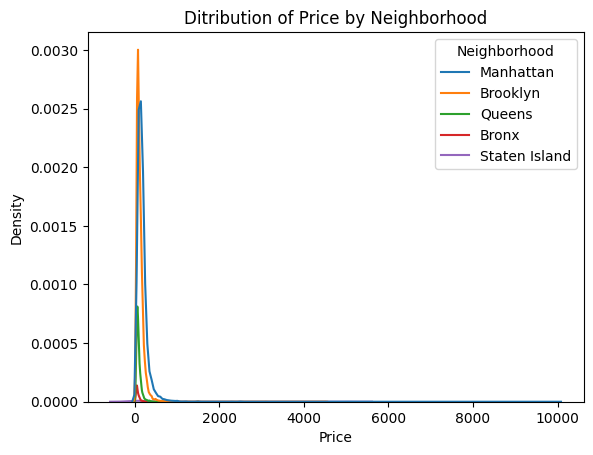

In [361]:
#Q2.1


# KDE plot of Price by Neighborhood
sns.kdeplot(data = df, x = 'Price', hue = 'Neighborhood')

plt.title('Ditribution of Price by Neighborhood')

Text(0.5, 1.0, 'Ditribution of Log(Price) by Neighborhood')

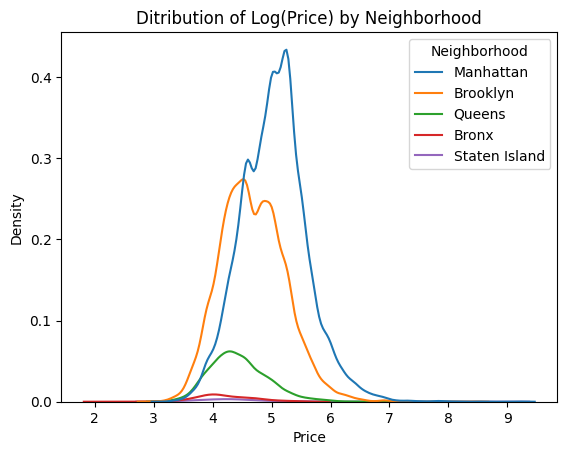

In [362]:
#Q2.1


# KDE plot of log(Price) by Neighborhood
sns.kdeplot(data = df, x = np.log(df['Price']), hue = 'Neighborhood')

plt.title('Ditribution of Log(Price) by Neighborhood')

In [363]:
#2.2 Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables
# (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients 
# in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). 
# How are the conditional group means and the estimated coefficients related?

# Creating dummy variable aka a column of zero's and one's
x_neighborhood = pd.get_dummies(df['Neighborhood'], dtype = 'int', drop_first = True)
x_neighborhood

#I chose to drop a category ("Bronx") and incorporate an intercept. Now the intercept of the regression will 
# represent the average price of "Bronx". 

,Brooklyn,Manhattan,Queens,Staten Island
0,0,1,0,0
1,1,0,0,0
2,0,1,0,0
3,1,0,0,0
4,0,1,0,0
...,...,...,...,...
22148,0,1,0,0
22149,1,0,0,0
22150,1,0,0,0
22151,1,0,0,0


In [364]:
#Q2.2 

# Defining my y and creating my x matrix with dummy variables and the numeric column "Review Scores Rating", 
# then creating a linear regression model and fitting it to the data. 
y = df['Price']

model = LinearRegression() #automatically adds the intercept to the model
model = model.fit(x_neighborhood, y)

print(f'Model intercept: {model.intercept_}')
model_df = pd.DataFrame({'var':model.feature_names_in_, 'coef':model.coef_ })
model_df


# Because I kept the intercept (drop_first = True), the coefficient in this model is the difference in price between
# the neighborhood and the baseline neighborhood (Bronx). Adding the intercept to a neighborhood's coefficient reproduces
# the exact conditional group mean from part 1.

Model intercept: 75.2764976958471


,var,coef
0,Brooklyn,52.470881
1,Manhattan,108.387789
2,Queens,21.580735
3,Staten Island,70.890169


In [365]:
# 2.3 Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.

x_score = df[['Review Scores Rating']]
y = df['Price']

model_score = LinearRegression()
model_score = model_score.fit(x_score, y)

print(f'Model intercept: {model_score.intercept_}')
model_score_df = pd.DataFrame({'var':model_score.feature_names_in_, 'coef':model_score.coef_ })
model_score_df

#The slope coefficient is 1.020827 which indicates that price and review scores ratings are positively correlated, as the
# review scores rating increases, the price of the listing increases by 1.020827 on average. 


Model intercept: 60.87839065711856


,var,coef
0,Review Scores Rating,1.020827


In [366]:
# 2.4 Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?


x = df.loc[:, ['Review Scores Rating', 'Neighborhood']]
x = pd.get_dummies(x, columns = ['Neighborhood'], dtype = 'int', drop_first = True)
y = df['Price']

model_neigh = LinearRegression()
model_neigh = model_neigh.fit(x, y)

print(f'Model intercept: {model_neigh.intercept_}')
model_neigh_df = pd.DataFrame({'var':model_neigh.feature_names_in_, 'coef':model_neigh.coef_ })
model_neigh_df

# The slope coefficient for "Review Scores Rating" is now 1.08116 which is higher than the slope coefficient of 1.020827 
# when neighborhood was not used as a dummy varible. The neighborhood's averages all decreased when "Review Scores Rating"
# was added to the model because it is positively correlated with price, so therefore neighborhoods have a slightly weaker
# influence to the predicted price than previously estimated as we can now see that the scores effected the change in prediction. 

Model intercept: -23.812561011683925


,var,coef
0,Review Scores Rating,1.081116
1,Neighborhood_Brooklyn,51.704240
2,Neighborhood_Manhattan,108.228737
3,Neighborhood_Queens,21.694600
4,Neighborhood_Staten Island,71.766552


In [367]:
# 2.5 Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?



In [368]:
# 2.6 Use cross validation to evaluate the models from parts 4, 5, and 6.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [369]:
# Q3.1 Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` 
# and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. 
# Which car types are the most expensive? Which have the most variance?

#loading data
df = pd.read_csv('./data/cars_hw.csv')

print(df.isna().sum()) #no null

#inspecting the data 
df['Price'].info() #price is a int, with 976 total entries and no null values.

print(df.head())

Unnamed: 0           0
Make                 0
Make_Year            0
Color                0
Body_Type            0
Mileage_Run          0
No_of_Owners         0
Seating_Capacity     0
Fuel_Type            0
Transmission         0
Transmission_Type    0
Price                0
dtype: int64
<class 'pandas.core.series.Series'>
RangeIndex: 976 entries, 0 to 975
Series name: Price
Non-Null Count  Dtype
--------------  -----
976 non-null    int64
dtypes: int64(1)
memory usage: 7.8 KB
   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0       

<Axes: xlabel='Price', ylabel='Density'>

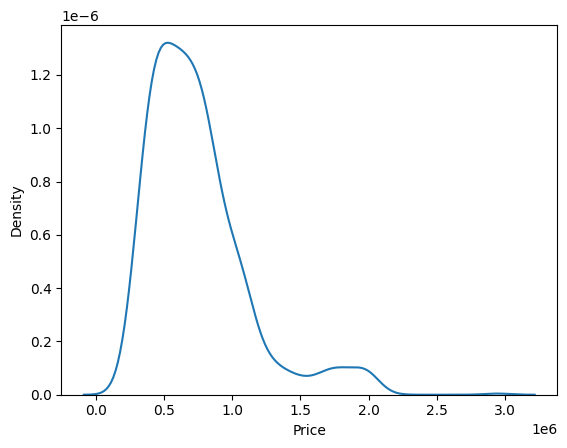

In [370]:
# Q3.1
# kde plot of price, highest density is around 550,000 based on graph only
sns.kdeplot(df, x = 'Price')


           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


<Axes: xlabel='Price', ylabel='Density'>

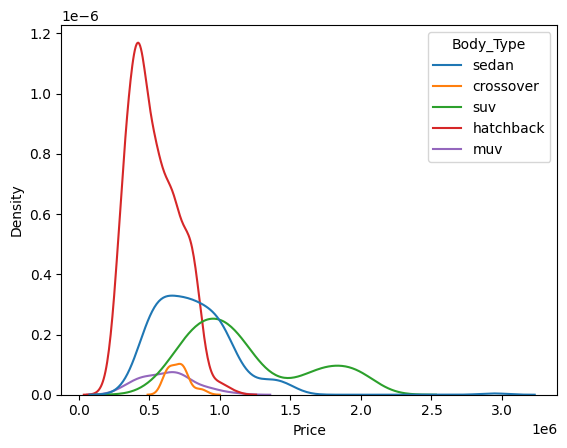

In [371]:
# Q3.1
# kde plot of price, grouped by body type, 

price_bodyType = df.groupby('Body_Type')['Price'].describe()
print(price_bodyType)

sns.kdeplot(df, x = 'Price', hue = 'Body_Type')


# As shown in the plot below and from the .describe() output, the suv body type vehicles are the most expensive on average with a mean of $1,176,495. The suv also has the 
# most variance (std^2) with a std of $417,479.028217 and a variance of $174,288,739,001. 

In [372]:
# 3.2 Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. 
# Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as 
# if it is categorical. Are the differences in price roughly linear in the number of seats?


x_seat_num = df[['Seating_Capacity']]
y = df['Price']

model_seat_num = LinearRegression()
model_seat_num = model_seat_num.fit(x_seat_num, y)

print(f'Model intercept: {model_seat_num.intercept_}')
model_seat_num_df = pd.DataFrame({'var':model_seat_num.feature_names_in_,'coef':model_seat_num.coef_ })
display(model_seat_num_df)

# The slope coefficient is 59,267.998037 which indicates that price and seating capactiy are positively correlated where for every added seat, the price of the vehicle 
# increases by $59,267.998037 on average.

x_seat_cat = pd.get_dummies(df['Seating_Capacity'], dtype='int', drop_first=True)

model_seat_cat = LinearRegression()
model_seat_cat = model_seat_cat.fit(x_seat_cat, y)

print(f'Model intercept: {model_seat_cat.intercept_}')
model_seat_cat_df = pd.DataFrame({'var':x_seat_cat.columns, 'coef':model_seat_cat.coef_ })
display(model_seat_cat_df)

#The differences in price are not roughly linear in the number of seats as the coefficients in the second dataframe below which represent the price difference between the 
# baseline of 4 seats and the other seating options do not solely increase and do not increase uniformly. For example, the coefficent from 5 to 6 increases, however from 
# 6 to 7 the coefficient decreases. 

Model intercept: 439032.0141018258


,var,coef
0,Seating_Capacity,59267.998037


Model intercept: 188000.00000001083


,var,coef
0,5,5.464839e+05
1,6,1.456000e+06
2,7,7.359487e+05
3,8,2.718000e+05


In [373]:
df.columns

Index(['Unnamed: 0', 'Make', 'Make_Year', 'Color', 'Body_Type', 'Mileage_Run',
       'No_of_Owners', 'Seating_Capacity', 'Fuel_Type', 'Transmission',
       'Transmission_Type', 'Price'],
      dtype='object')

In [374]:
# Q3.3 Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation 
# to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 

from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score


df['age_vehicle'] = 2026 - df['Make_Year']

x_age = df[['age_vehicle']]
y = df['Price']
cv_scores_mean = []

for degree in range (1, 11):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    x_poly = poly.fit_transform(x_age)
    model_age = LinearRegression()
    
    #cross validation
    cv_scores = cross_val_score(model_age, x_poly, y, cv=10)
    cv_scores_mean.append(cv_scores.mean())

max_cv_score = max(cv_scores_mean)
degree = cv_scores_mean.index(max_cv_score) + 1


print(f"On average, the most optimal number of powers of age is {degree} with a mean accuracy of {max_cv_score}")


On average, the most optimal number of powers of age is 3 with a mean accuracy of 0.20679554482904688


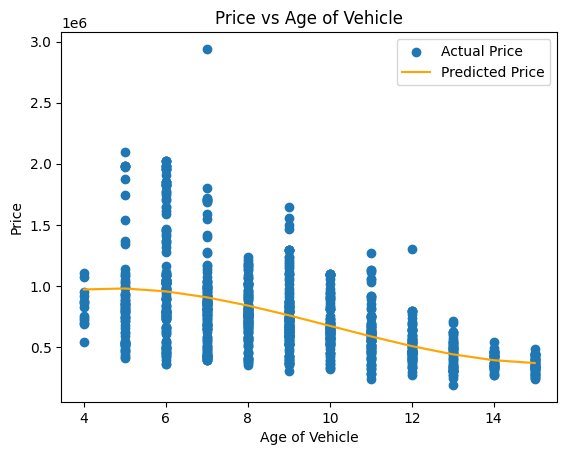

In [375]:
# Q3.4 Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?
poly_optimal = PolynomialFeatures(degree=degree, include_bias=False)
x_poly_optimal = poly_optimal.fit_transform(x_age)

model_optimal = LinearRegression()
model_optimal.fit(x_poly_optimal, y)


plt.scatter(x = df['age_vehicle'], y = df['Price'], label = 'Actual Price')
sns.lineplot(x = df['age_vehicle'], y = model_optimal.predict(x_poly_optimal), label = 'Predicted Price', color='orange')
plt.title('Price vs Age of Vehicle')
plt.xlabel('Age of Vehicle')
plt.ylabel('Price')
plt.show()

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?

In [376]:
# Q4.0

df = pd.read_csv('./data/heart_hw.csv')
print(df.head())
print(df.nunique())
print(df.info())
print(df.isna().sum())


   Unnamed: 0  age transplant  y
0           1   53    control  0
1           2   43    control  0
2           3   52    control  0
3           4   52    control  0
4           5   54    control  0
Unnamed: 0    103
age            35
transplant      2
y               2
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  103 non-null    int64 
 1   age         103 non-null    int64 
 2   transplant  103 non-null    object
 3   y           103 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 3.3+ KB
None
Unnamed: 0    0
age           0
transplant    0
y             0
dtype: int64


In [377]:
# Q4.1 Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. 
# Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart
# transplant interventions?

transplant_count = df['transplant'].value_counts() #69 transplant and 34 control, in this order

surviver_count = df.groupby(df['transplant'])['y'].sum() # 4 control and 24 transplant, in this order

control_prop = surviver_count['control']/transplant_count['control']
treatment_prop = surviver_count['treatment']/transplant_count['treatment']
print(f'The proportion of people who survive in the control group is {control_prop} and the proportion of people who survive in the treatment group is {treatment_prop}')


ate = treatment_prop-control_prop
print(f'The average treatment effect (ATE) on three-year survival for heart transplant interventions is {ate}')


The proportion of people who survive in the control group is 0.11764705882352941 and the proportion of people who survive in the treatment group is 0.34782608695652173
The average treatment effect (ATE) on three-year survival for heart transplant interventions is 0.23017902813299232


In [378]:
# Q4.2 Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and 
# transplant coefficient to the numbers you computed in part 1. 

# needed to do this for transplant because they were categorical string variables, so now we have 
# integers so we can run the regression.
df['transplant'] = df['transplant'].map({'control': 0, 'treatment': 1})

x = df[['transplant']]
y = df['y']

model_transplant = LinearRegression()
model_transplant = model_transplant.fit(x,y)

print(f'Model intercept: {model_transplant.intercept_}')
model_transplant_df = pd.DataFrame({'var':model_transplant.feature_names_in_, 'coef':model_transplant.coef_ })
model_transplant_df

# They are the same! The intercept and the coefficent from the regression are the same because the regression 
# is exactly modeling the difference in means between the two groups of obseravtions. 


Model intercept: 0.11764705882352974


,var,coef
0,transplant,0.230179


Model intercept: 0.701956972174095


,var,coef
0,transplant,0.264702
1,age,-0.013607


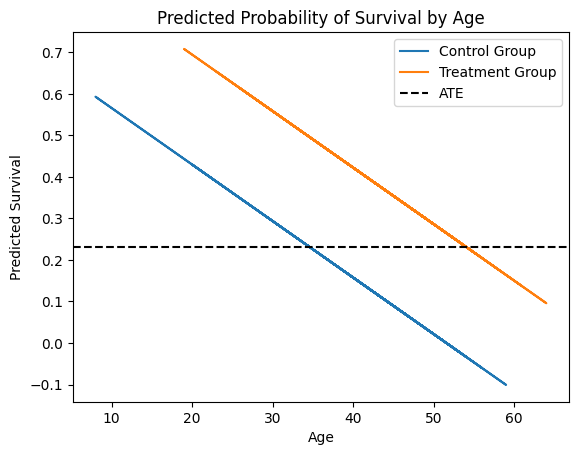

In [379]:
# Q4.3 Regress `y` on transplant and age. How does the coefficient on transplant change when you control 
# for age? What do the intercept and slope represent? Plot the predicted probability of survival by age, 
# and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating
# the impact of a transplant?


x_trans_age = df[['transplant', 'age']]

model_trans_age = LinearRegression()
model_trans_age = model_trans_age.fit(x_trans_age, y)


print(f'Model intercept: {model_trans_age.intercept_}')
model_trans_age_df = pd.DataFrame({'var':model_trans_age.feature_names_in_, 'coef':model_trans_age.coef_ })
display(model_trans_age_df)

df['predicted_survival_trans_age'] = model_trans_age.predict(x_trans_age)

control = df[df['transplant'] == 0]

treat = df[df['transplant'] == 1]

plt.plot(control['age'], control['predicted_survival_trans_age'], label='Control Group')
plt.plot(treat['age'], treat['predicted_survival_trans_age'], label='Treatment Group')
plt.axhline(y=ate, linestyle='--', color='black', label='ATE')

plt.title('Predicted Probability of Survival by Age')
plt.xlabel('Age')
plt.ylabel('Predicted Survival')
plt.legend()
plt.show()

#The ATE overestimates the effect of transplant at younger ages (for control at 55 or younger, 
# for treatment at 35 or younger), where the dashed line is above the vertical gap between the 
# treatment and control lines. It underestimates the effect at older ages, where the dashed 
# line is below the true gap between the two lines.

Model intercept: 0.35486517529945905


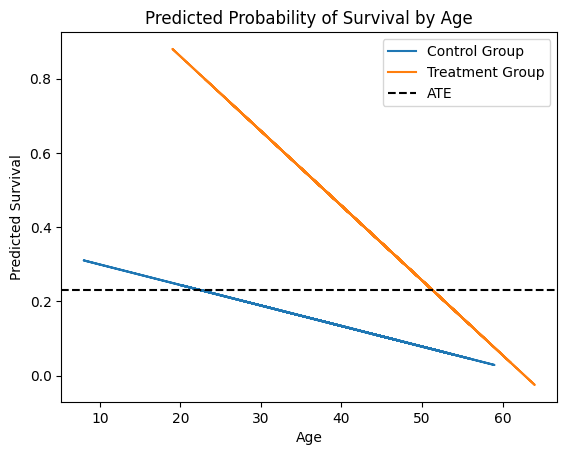

In [380]:
# Q4.4 Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3.
# How does allowing age and transplant to interact change your predictions? What pattern do you notice?

df['transplant_age'] = df['transplant']*df['age']

x_multiple = df[['transplant', 'age', 'transplant_age']]

model_multiple = LinearRegression()
model_multiple = model_multiple.fit(x_multiple, y)

print(f'Model intercept: {model_multiple.intercept_}')
model_multiple_df = pd.DataFrame({'var':model_multiple.feature_names_in_, 'coef':model_multiple.coef_ })
model_multiple_df

df['predicted_surviva_multi'] = model_multiple.predict(x_multiple)

control = df[df['transplant'] == 0]

treat = df[df['transplant'] == 1]

plt.plot(control['age'], control['predicted_surviva_multi'], label='Control Group')
plt.plot(treat['age'], treat['predicted_surviva_multi'], label='Treatment Group')
plt.axhline(y=ate, linestyle='--', color='black', label='ATE')

plt.title('Predicted Probability of Survival by Age')
plt.xlabel('Age')
plt.ylabel('Predicted Survival')
plt.legend()
plt.show()

# I notice that both stilll decline with age, however, the treatment group is more steep 
# which means that for younger patients this is a good sign, however, treament is not as
# good for older patients. Now the ate line underestimates for younger ages and overestimates 
# for older ages.

In [381]:
# Q4.5 Use 10-fold cross validation to evaluate the predictive accuracy of these models. 


model_list = [model_transplant, model_trans_age, model_multiple]
cv_scores_mean = []
x_vars = [x, x_trans_age, x_multiple]

for i in range(len(model_list)):
    model = model_list[i]
    x_var = x_vars[i]    
        #cross validation
    cv_scores = cross_val_score(model, x_var, y, cv=10)
    cv_scores_mean.append(cv_scores.mean())

max_cv_score_index = cv_scores_mean.index(max(cv_scores_mean))

#needed to have name arrays because model_list would output LinearRegression 
model_names = ["model_transplant", "model_trans_age", "model_multiple"]
x_names = ["transplant", "transplant and age", "transplant, age, and transplant*age"]

optimal_model = model_names[max_cv_score_index]
print(f'The most optimal model is {optimal_model} which uses the x variable {x_names[max_cv_score_index]} as the mean accuracy is {cv_scores_mean[max_cv_score_index]}')

The most optimal model is model_transplant which uses the x variable transplant as the mean accuracy is -0.40439122900114255


In [382]:
# Q4.6 Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?

# I would be concerned with overfitting the model to the data by using too many variables and operations on the data. As shown from the analysis
# from 4.5, we see that the x variable transplant was the most accuracy, and models using transplant and age in various ways had lower mean accuracy. 
# Also, I would be concerned with using a model in general that is not very accurate as the most accurate model was only 40% accurate. Using such a 
# model to prioritize transplant access could lead to many people being misclassified and not receiving the transplants they need.